# Probabilistic programming with `mixle.ppl`

`mixle.ppl` is a one-line modeling surface over mixle. There is one rule: a model is ordinary distribution construction where a parameter slot may hold

- a value - fixed,
- the token `free` - estimate it (maximum likelihood / EM), or
- another distribution - make it random (a Bayesian prior).

That's the whole language. You build a model, call `.fit(data)`, and query it with `.sample`, `.log_prob`, `.posterior`, `.predict`, `.params`. The inference engine is chosen for you - closed-form EM and exact conjugate posteriors where the structure allows, MCMC/HMC/variational when you ask - but the surface stays the same.

This tutorial is a tour of that surface. For the distribution library underneath, see distributions_and_combinators; for the raw estimation/MCMC machinery the PPL sits on, see fitting_and_estimation and mcmc_sampling.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from mixle.ppl import (Normal, Poisson, Gamma, Exponential, Bernoulli, Beta, Categorical,
                      Mix, Markov, Seq, MVN, Field, Group, free, compare)
rng = np.random.RandomState(0)

## Maximum likelihood, in one line

`free` marks a parameter to estimate. `.fit` runs mixle's EM (closed-form M-step, no learning rate). The fitted model reports its parameters in the same parameterization you wrote and answers the usual queries.


In [2]:
data = list(rng.normal(5.0, 2.0, 4000))
m = Normal(free, free).fit(data)
print('Normal(free, free) ->', m.params)                 # {'mean': ~5, 'sd': ~2}
print('sample(3)          ->', np.round(m.sample(3), 2))
print('log_prob(5.0)      ->', round(float(m.log_prob(5.0)), 3))

counts = list(rng.poisson(3.5, 4000).astype(float))
print('Poisson(free)      ->', Poisson(free).fit(counts).params)

Normal(free, free) -> {'mean': 4.949094536281618, 'sd': 1.963774131021136}
sample(3)          -> [1.5  3.2  7.97]
log_prob(5.0)      -> -1.594
Poisson(free)      -> {'rate': 3.46025}


## Priors are just distributions - and conjugate Bayes is exact

Put a distribution in a slot and it becomes a prior. When the prior is conjugate to the likelihood, `.fit` returns the closed-form posterior - no iteration, no sampling, one O(N) pass. Name the random parameter to query its posterior by name.


posterior summary: {'mean': 4.94904504583116, 'posterior': 'Normal', 'hyper': {'mean': 4.94904504583116, 'sd': 0.03162261848898663}}
Poisson-Gamma  rate = 3.46
Bernoulli-Beta p    = 0.307


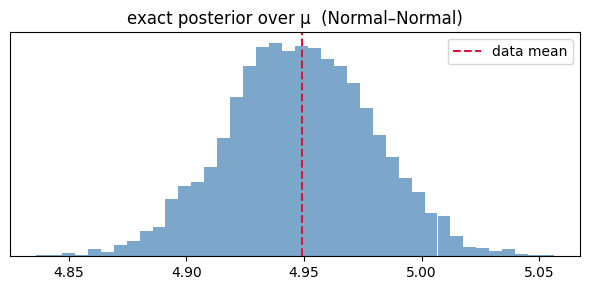

In [3]:
mu = Normal(0, 10, name='mu')               # prior on the unknown mean
m  = Normal(mu, 2.0).fit(data)              # known sd -> conjugate Normal-Normal
print('posterior summary:', m.result.summary()['mu'])

# other conjugate pairs, one line each
print('Poisson-Gamma  rate =', round(Poisson(Gamma(2, 1, name='rate')).fit(counts).dist.lam, 3))
flips = list((rng.random(2000) < 0.3).astype(float))
print('Bernoulli-Beta p    =', round(Bernoulli(Beta(1, 1, name='p')).fit(flips).dist.p, 3))

draws = m.posterior('mu')                    # exact posterior draws, by name
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(draws, bins=40, density=True, color='steelblue', alpha=0.7)
ax.axvline(np.mean(data), color='crimson', ls='--', label='data mean')
ax.set_title('exact posterior over µ  (Normal–Normal)'); ax.set_yticks([]); ax.legend()
plt.tight_layout(); plt.show()

## When it isn't conjugate: pick an engine with `how=`

The same model fits under different inference engines via `how=`. `auto` (the default) walks hierarchical → conjugate → MAP → EM; ask for `mcmc`/`hmc`/`vi`/`vmp` when you want a full or approximate posterior.

| `how` | engine | when |
|---|---|---|
| `"em"` | EM / MLE (parallel backends) | plain `free` models |
| `"conjugate"` | closed-form posterior | conjugate prior + known other params |
| `"map"` | maximize the joint | priors, point estimate |
| `"vi"` | mean-field ADVI | non-conjugate priors, fast approximate posterior |
| `"vmp"` | variational message passing | conjugate-exponential models (e.g. unknown mean and precision) |
| `"mcmc"` | adaptive Metropolis | full posterior, high throughput |
| `"hmc"` | Hamiltonian Monte Carlo | full posterior, best mixing |
| `"hierarchical"` | conjugate VB/EM random effects | `.each()` group priors |
| `"nuts"` | no-U-turn HMC (auto-tuned) | full posterior, hands-off |
| `"ensemble"` | multi-chain sampler (R-hat / ESS) | convergence diagnostics |
| `"vi"`, `family=`, `alpha=` | ADVI: mean-field / full-rank / tilted | fast approximate posteriors |


MCMC acc 0.47  ESS 153
HMC  acc 1.00  ESS 1000


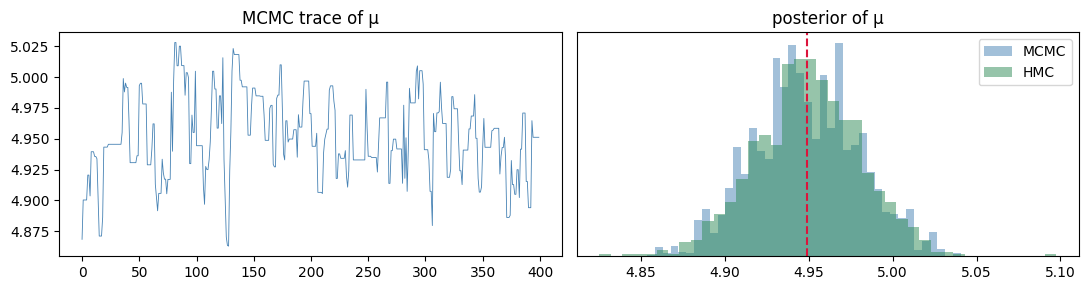

In [4]:
mu = Normal(0, 10, name='mu')
mc  = Normal(mu, free).fit(data, how='mcmc', draws=2000, burn=1000, rng=np.random.RandomState(1))
hmc = Normal(mu, free).fit(data, how='hmc',  draws=1000, burn=500,  rng=np.random.RandomState(2))
print('MCMC acc %.2f  ESS %.0f' % (mc.result.acceptance_rate,
      float(np.atleast_1d(mc.result.raw.effective_sample_size()).min())))
print('HMC  acc %.2f  ESS %.0f' % (hmc.result.acceptance_rate,
      float(np.atleast_1d(hmc.result.raw.effective_sample_size()).min())))

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(mc.posterior('mu')[:400], lw=0.6, color='steelblue'); ax[0].set_title('MCMC trace of µ')
ax[1].hist(mc.posterior('mu'), bins=40, density=True, alpha=0.5, color='steelblue', label='MCMC')
ax[1].hist(hmc.posterior('mu'), bins=40, density=True, alpha=0.5, color='seagreen', label='HMC')
ax[1].axvline(np.mean(data), color='crimson', ls='--'); ax[1].set_title('posterior of µ'); ax[1].legend(); ax[1].set_yticks([])
plt.tight_layout(); plt.show()

## Regression and GLMs with `Field`

A linear predictor in a parameter slot makes a regression; the outer family sets the link. Coefficients are `free` (MLE) or Normal priors (Bayesian / ridge). The response goes in positionally; covariates via `given=`.

```
Normal(free*Field('x') + free, free)    # linear regression  (identity link)
Bernoulli(free*Field('x') + free)       # logistic regression (logit link)
Poisson(free*Field('x') + free)         # Poisson regression  (log link)
```


linear   : {'x': 1.97, 'intercept': -0.97}
logistic : {'z': 1.5, 'intercept': -0.37}


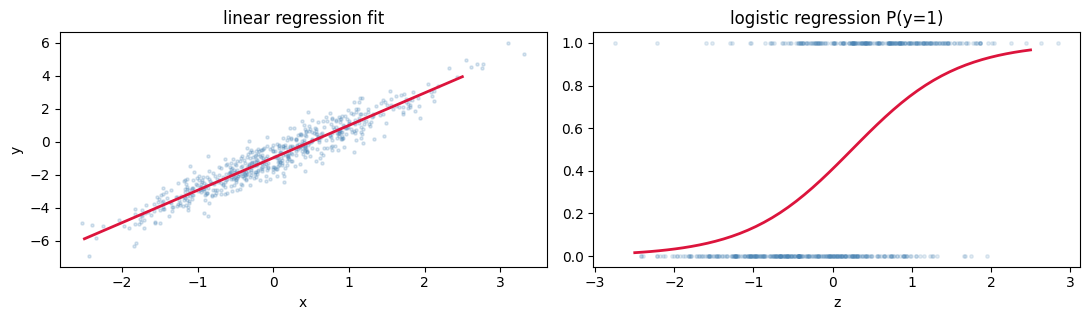

In [5]:
# linear regression: y = 2x - 1 + noise
xs = rng.normal(0, 1, 600); ys = 2.0 * xs - 1.0 + rng.normal(0, 0.6, 600)
lin = Normal(free * Field('x') + free, free).fit(list(ys), given={'x': list(xs)})
print('linear   :', {k: round(v['mean'], 2) for k, v in lin.params.items()})

# logistic regression: P(y=1) = sigmoid(1.5 z - 0.5)
zs = rng.normal(0, 1, 600); pz = 1 / (1 + np.exp(-(1.5 * zs - 0.5)))
yb = (rng.random(600) < pz).astype(float)
logit = Bernoulli(free * Field('z') + free).fit(list(yb), given={'z': list(zs)})
print('logistic :', {k: round(v['mean'], 2) for k, v in logit.params.items()})

grid = np.linspace(-2.5, 2.5, 50)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].scatter(xs, ys, s=5, alpha=0.2, color='steelblue')
ax[0].plot(grid, lin.result.predict({'x': list(grid)}), color='crimson', lw=2)
ax[0].set_title('linear regression fit'); ax[0].set_xlabel('x'); ax[0].set_ylabel('y')
ax[1].scatter(zs, yb, s=6, alpha=0.15, color='steelblue')
ax[1].plot(grid, logit.result.predict({'z': list(grid)}), color='crimson', lw=2)
ax[1].set_title('logistic regression P(y=1)'); ax[1].set_xlabel('z')
plt.tight_layout(); plt.show()

## Hierarchical models: partial pooling

Mark a prior with `.each()` and a global parameter becomes a per-group random effect; the data is a list of groups. Inference is a conjugate E-step (exact per-group posteriors) plus an empirical-Bayes population M-step. Groups with little data are shrunk toward the population mean - the defining benefit of hierarchical modeling, in one line.


population: m=0.39 tau=1.19 sigma=2.99


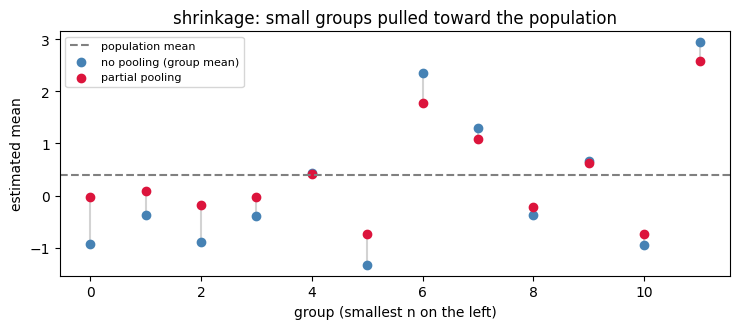

In [6]:
# 12 groups with varying sizes; small groups should shrink toward the grand mean
true_means = rng.normal(0, 1.2, 12)
sizes = [40, 35, 30, 25, 20, 15, 12, 9, 7, 5, 4, 3]
groups = [list(rng.normal(mu, 3.0, n)) for mu, n in zip(true_means, sizes)]  # noisy within-group

fit = Normal(Normal(0, 100).each(), free).fit(groups)
pop = fit.result.hyper
pooled = np.array(fit.result.group_means)
raw = np.array([np.mean(g) for g in groups])          # no-pooling (per-group MLE)
print('population: m=%.2f tau=%.2f sigma=%.2f' % (pop['m'], pop['tau'], pop['sigma']))

order = np.argsort(sizes)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.axhline(pop['m'], color='gray', ls='--', label='population mean')
ax.scatter(range(12), raw[order], color='steelblue', label='no pooling (group mean)')
ax.scatter(range(12), pooled[order], color='crimson', label='partial pooling')
for i, o in enumerate(order):
    ax.plot([i, i], [raw[o], pooled[o]], color='lightgray', zorder=0)
ax.set_xlabel('group (smallest n on the left)'); ax.set_ylabel('estimated mean')
ax.set_title('shrinkage: small groups pulled toward the population'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [7]:
# Mixed effects: fixed slope + per-group random intercept  (lme4's  y ~ x + (1|g))
n = 600; x = rng.normal(0, 1, n); g = rng.randint(0, 8, n)
re = rng.normal(0, 1.5, 8); y = 1.5 * x + re[g] + rng.normal(0, 0.5, n)
mm = Normal(free * Field('x') + free + Group('g'), free).fit(
        list(y), given={'x': list(x), 'g': list(g)})
print('fixed effects   :', {k: round(v['mean'], 2) for k, v in mm.result.coefficients.items()})
print('variance comps  : tau=%.2f sigma=%.2f' % (mm.result.tau, mm.result.sigma))

fixed effects   : {'x': 1.49, 'intercept': -0.02}
variance comps  : tau=1.20 sigma=0.53


## Mixtures and structured models

`Mix` is a mixture (EM with k-means++ init, so well-separated clusters separate reliably); `.posterior(data)` exposes the responsibilities. `Markov`, `Seq`, `MVN`, and the state-space models are all one-liners with the same `.fit`/query surface.


Mix means        : [-4.03, 3.99]
responsibilities : (2400, 2) (N x K soft assignments)
Markov (HMM)     : (2, 2) transition matrix
MVN(2)           : {'mean': array([ 0.00046161, -0.02573436]), 'cov': array([[0.98758358, 0.63286743],
       [0.63286743, 1.10131967]])}


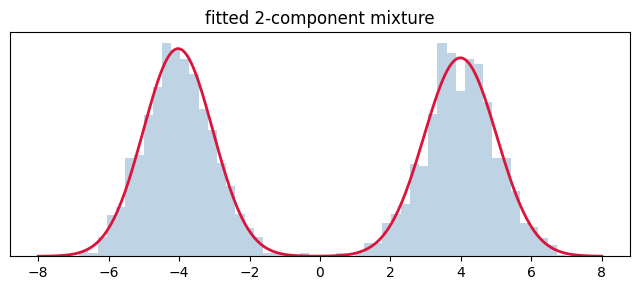

In [8]:
gm = list(np.r_[rng.normal(-4, 1, 1200), rng.normal(4, 1, 1200)])
mix = Mix([Normal(free, free), Normal(free, free)]).fit(gm)
print('Mix means        :', sorted(round(c.mu, 2) for c in mix.dist.components))
print('responsibilities :', mix.posterior(gm).shape, '(N x K soft assignments)')

# 2-state Gaussian HMM, an iid sequence model, and a 2-D Gaussian — each one line
seqs = [list(rng.normal(0, 1, 15)) for _ in range(40)]
print('Markov (HMM)     :', Markov(Normal(free, free), states=2).fit(seqs).params['transitions'].shape, 'transition matrix')
pts = [list(p) for p in rng.multivariate_normal([0, 0], [[1, 0.6], [0.6, 1]], 400)]
print('MVN(2)           :', MVN(2).fit(pts).params)

fig, ax = plt.subplots(figsize=(6.5, 3))
g = np.linspace(-8, 8, 300)
ax.hist(gm, bins=60, density=True, alpha=0.35, color='steelblue')
ax.plot(g, np.exp([mix.log_prob(v) for v in g]), color='crimson', lw=2)
ax.set_title('fitted 2-component mixture'); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Random-variable algebra and conditioning

Random variables compose algebraically. Affine maps and `.exp()` are exact (with the Jacobian); sums convolve (exact for conjugate-stable pairs - Normal, Poisson, Gamma - Monte-Carlo otherwise). `.given(event)` conditions a variable on an event (truncation).


3·N(0,1)+1     mean=1.00 var=9.01
N(0,1)+N(5,2)  mean=5.02 var=5.00
P(x>0)=0.50  E[x | x>0]=0.82


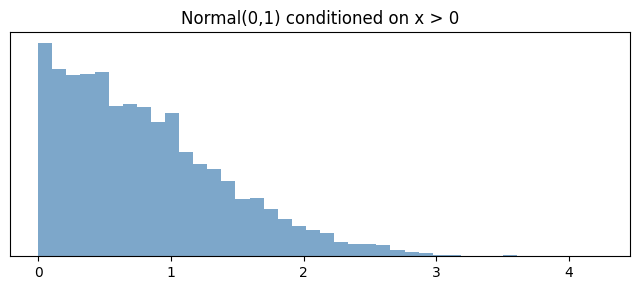

In [9]:
affine = 3 * Normal(0, 1) + 1                 # -> Normal(1, 9), exact
print('3·N(0,1)+1     mean=%.2f var=%.2f' % (affine.mean(), affine.var()))
conv = Normal(0, 1) + Normal(5, 2)           # convolution -> N(5, sqrt(5))
print('N(0,1)+N(5,2)  mean=%.2f var=%.2f' % (conv.mean(), conv.var()))

x = Normal(0, 1)
q = x.given(x > 0)                           # condition on x > 0 (half-normal)
print('P(x>0)=%.2f  E[x | x>0]=%.2f' % (q.prob_of_event(), float(np.mean(q.sample(4000)))))

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(q.sample(5000), bins=40, density=True, color='steelblue', alpha=0.7)
ax.set_title('Normal(0,1) conditioned on x > 0'); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Model comparison and the escape hatch

`compare` scores fitted models by log-likelihood, AIC, and BIC. And whatever the model, `.dist` is always the underlying mixle distribution - the full library API is one attribute away.


In [10]:
m1 = Normal(free, free).fit(gm)
m2 = Mix([Normal(free, free), Normal(free, free)]).fit(gm)
for row in compare([m1, m2], gm):
    print('%-22s loglik=%9.0f  AIC=%9.0f  BIC=%9.0f' % (row['model'], row['loglik'], row['aic'], row['bic']))
print('\nescape hatch  m2.dist ->', type(m2.dist).__name__, '(full mixle.stats API available)')

MixtureDistribution    loglik=    -5088  AIC=    10189  BIC=    10223
GaussianDistribution   loglik=    -6810  AIC=    13625  BIC=    13636

escape hatch  m2.dist -> MixtureDistribution (full mixle.stats API available)


## Approximate inference and posterior-predictive checks

When a posterior isn't conjugate, `how='vi'` (mean-field ADVI) and `how='vmp'` (variational message passing - for conjugate-exponential models such as an unknown mean and precision) give fast approximate posteriors. `how='hierarchical'` is the engine behind `.each()`. And `predict` draws from the posterior-predictive - new data integrating over parameter uncertainty - which we overlay on the observed data as a model check.


how='vi'  : {'mean': 4.98, 'sd': 1.97}
how='vmp' : {'mean': 4.98, 'sd': 1.95}  (unknown mean AND precision)


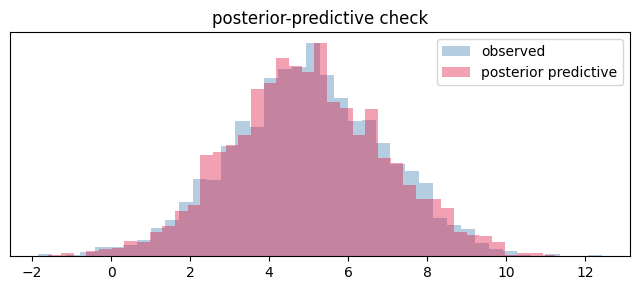

In [11]:
dd = list(rng.normal(5, 2, 2000))
print("how='vi'  :", {k: round(v, 2) for k, v in Normal(Normal(0, 10), free).fit(dd, how='vi').params.items()})
print("how='vmp' :", {k: round(v, 2) for k, v in Normal(Normal(0, 10), Gamma(1, 1)).fit(dd, how='vmp').params.items()},
      ' (unknown mean AND precision)')

post = Normal(Normal(0, 10, name='mu'), 2.0).fit(dd)        # conjugate posterior
pp = np.array(post.predict(2000))                            # posterior-predictive draws
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(dd, bins=40, density=True, alpha=0.4, color='steelblue', label='observed')
ax.hist(pp, bins=40, density=True, alpha=0.4, color='crimson', label='posterior predictive')
ax.set_title('posterior-predictive check'); ax.legend(); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Constraints: domain knowledge in the fit

A slot can carry more than a value, `free`, or a prior - the fit can carry constraints. Name the parameters you want to constrain (a named prior for a scalar, `free(dim, name=)` for a vector) and pass `constraints=[...]` to `.fit`. Hard inequalities (`a < b`, `ne`) are enforced by rejection and route to `map`/`mcmc`/`hmc`; soft constraints (`eq`, `increasing`/`convex`/`monotone`, `lipschitz`, `ode_residual`) add a smooth penalty whose weight is `penalty=`. The worked, visual treatment is in constrained_inference; here is the surface.


In [12]:
from mixle.ppl import eq, increasing, DiagGaussian

# (a) hard inequality: order a mixture's means so labels are identifiable
mu0 = Normal(0, 10, name='mu0'); mu1 = Normal(0, 10, name='mu1')
gm = list(np.r_[rng.normal(-2, 1, 400), rng.normal(3, 1, 600)])
ord_fit = Mix([Normal(mu0, 1.0), Normal(mu1, 1.0)]).fit(
    gm, how='mcmc', constraints=[mu0 < mu1], draws=300, burn=150, rng=np.random.RandomState(1))
sm = ord_fit.summary()
print('ordered means : mu0=%.2f < mu1=%.2f' % (sm['mu0']['mean'], sm['mu1']['mean']))

# (b) soft equality with a penalty weight: fix a Beta's concentration a+b=10
a = Normal(2, 5, name='a'); b = Normal(2, 5, name='b')
bdata = list(rng.beta(3, 7, 500))
eq_fit = Beta(a, b).fit(bdata, how='auto', constraints=[eq(a + b, 10.0)], penalty=500.0)
print('eq a+b=10     : a=%.2f b=%.2f sum=%.3f' % (eq_fit.params['a'], eq_fit.params['b'],
                                                  eq_fit.params['a'] + eq_fit.params['b']))

# (c) shape constraint: force a fitted mean-vector to be monotone increasing
v = free(5, name='v')
X = np.stack([rng.normal(loc, 0.5, 300) for loc in [0, 2, 1, 3, 4]], axis=1).tolist()
shp = DiagGaussian(5, mean=v).fit(X, how='map', constraints=[increasing(v)])
print('increasing(v) :', np.round(shp.params['mean'], 2),
      '(monotone:', bool(np.all(np.diff(shp.params['mean']) >= -1e-6)), ')')

ordered means : mu0=-2.07 < mu1=3.01
eq a+b=10     : a=2.87 b=7.13 sum=9.995
increasing(v) : [2.   2.   2.   2.   2.11] (monotone: True )


## More inference engines: NUTS, ensemble, and ADVI variants

Beyond `mcmc`/`hmc`, three more engines round out the `how=` surface. `how='nuts'` is auto-tuned Hamiltonian Monte Carlo (no step-size/leapfrog tuning). `how='ensemble'` runs multiple chains and reports the Gelman-Rubin $\hat R$ and effective sample size (keys `_rhat`/`_ess` in `summary()`). And `how='vi'` (ADVI) accepts `family='fullrank'` (correlated Gaussian posterior vs the default mean-field), a tilted Rényi objective via `alpha=`, and minibatch SGVB via `batch_size=`. VI run metadata lives on `.result.raw`.


In [13]:
dd = list(rng.normal(5.0, 2.0, 800))
model = Normal(Normal(0, 10, name='mu'), free)

nuts = model.fit(dd, how='nuts', draws=400, burn=400)
print("how='nuts'     : mu=%.3f  acceptance=%.2f" % (
    nuts.summary()['mu']['mean'], nuts.result.acceptance_rate))

ens = model.fit(dd, how='ensemble', draws=400, burn=200, chains=4)
es = ens.summary()
print("how='ensemble' : mu=%.3f  R-hat=%.3f  ESS=%.0f  (%d chains)" % (
    es['mu']['mean'], es['_rhat']['mu'], es['_ess'], es['_n_chains']))

for fam in ['meanfield', 'fullrank']:
    f = model.fit(dd, how='vi', family=fam, steps=300)
    print("how='vi' %-9s: mu=%.3f  objective=%.1f  family=%s" % (
        fam, f.summary()['mu']['mean'], f.result.raw.objective, f.result.raw.family))
talpha = model.fit(dd, how='vi', alpha=0.5, steps=300)
print("how='vi' alpha : mu=%.3f  kind=%s" % (
    talpha.summary()['mu']['mean'], talpha.result.raw.objective_kind))
mb = model.fit(dd, how='vi', batch_size=64, steps=300)
print("how='vi' batch : mu=%.3f  batch_size=%d (minibatch SGVB)" % (
    mb.summary()['mu']['mean'], mb.result.raw.batch_size))

how='nuts'     : mu=4.806  acceptance=1.00


how='ensemble' : mu=4.805  R-hat=1.010  ESS=3647  (4 chains)


how='vi' meanfield: mu=4.812  objective=-1710.2  family=meanfield


how='vi' fullrank : mu=4.816  objective=-1710.2  family=fullrank


how='vi' alpha : mu=4.847  kind=renyi_tilted


how='vi' batch : mu=4.726  batch_size=64 (minibatch SGVB)


## Heteroskedastic regression: a predictor in the scale slot

A linear predictor isn't limited to the mean. Put one in the scale slot too and the noise varies with the covariates - a location-scale (heteroskedastic) regression with a log link on the scale. The fitted `.result` exposes `.coefficients` (mean) and `.scale_coefficients` (log-scale), and `predict` returns both `loc` and `scale` per input.


mean  coeffs : {'x': 2.05, 'intercept': 0.93}
scale coeffs : {'x': 0.39, 'intercept': -0.47} (log link)


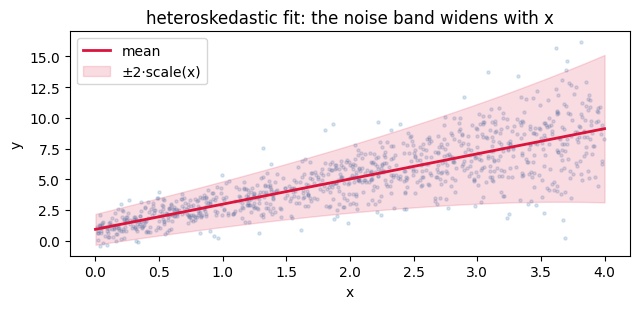

In [14]:
n = 1000; x = rng.uniform(0, 4, n)
y = (1.0 + 2.0 * x) + np.exp(-0.5 + 0.4 * x) * rng.normal(size=n)   # noise GROWS with x

het = Normal(free * Field('x') + free, free * Field('x') + free).fit(list(y), given={'x': list(x)})
print('mean  coeffs :', {k: round(v['mean'], 2) for k, v in het.result.coefficients.items()})
print('scale coeffs :', {k: round(v['mean'], 2) for k, v in het.result.scale_coefficients.items()}, '(log link)')

grid = np.linspace(0, 4, 60)
pred = het.result.predict({'x': list(grid)})
loc, scale = np.asarray(pred['loc']), np.asarray(pred['scale'])
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.scatter(x, y, s=5, alpha=0.2, color='steelblue')
ax.plot(grid, loc, color='crimson', lw=2, label='mean')
ax.fill_between(grid, loc - 2*scale, loc + 2*scale, color='crimson', alpha=0.15, label='±2·scale(x)')
ax.set_title('heteroskedastic fit: the noise band widens with x'); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
plt.tight_layout(); plt.show()